# Python with MongoDB

Helpful learning resources: https://www.tutorialspoint.com/mongodb/index.htm

## Libraries and Settings

In [1]:
"""Connect to MongoDB, insert car data, run queries, and visualize results."""

#Libraries

import json                                                 #JSON-Dateien einlesen und verarbeiten
import os                                                   #Betriebssystem- und Pfadfunktionen verwenden
import platform                                             #Informationen zum Betriebssystem/System auslesen
import warnings                                             #Warnmeldungen steuern
from datetime import datetime                               #Aktuelles Datum und aktuelle Uhrzeit verwenden
from platform import python_version                         #Installierte Python-Version auslesen

import matplotlib.pyplot as plt                             #Diagramme und Visualisierungen erstellen
import pandas as pd                                         #Mit DataFrames und tabellarischen Daten arbeiten
from pymongo import MongoClient                             #Verbindung zu MongoDB herstellen
from pymongo.errors import PyMongoError                     #MongoDB-/PyMongo-Fehler abfangen

#Settings
warnings.filterwarnings("ignore")                           #Warnmeldungen ausblenden

#Use dark background for plots
plt.style.use("dark_background")                            #Dunkles Design für Matplotlib-Diagramme aktivieren

#Current working directory
print(os.getcwd())                                          #Aktuellen Arbeitsordner anzeigen

/workspace


## Connect to the MongoDB server and list databases

In [2]:
#Connect to the MongoDB server
client = MongoClient("mongodb://mongo:27017/")          #Verbindung zum MongoDB-Server im Container "mongo" auf Port 27017 herstellen

#List databases
databases = client.list_database_names()                #Namen aller vorhandenen MongoDB-Datenbanken abrufen
print("Connected to MongoDB. Databases:", databases)    #Erfolgreiche Verbindung und vorhandene Datenbanken ausgeben

Connected to MongoDB. Databases: ['admin', 'config', 'local']


## Read and insert data

In [3]:
# Create / access the specific database and collection

db = client["car_database"]                                                 #Datenbank car_database auswählen bzw. bei Bedarf später automatisch anlegen
collection = db["car_collection"]                                           #Collection car_collection innerhalb der Datenbank auswählen

# Read data from JSON file

with open("/workspace/data/car_data.json", "r", encoding="utf-8") as file:  #JSON-Datei öffnen und nach dem Block automatisch wieder schliessen
    example_data = json.load(file)                                          #JSON-Inhalt einlesen und als Python-Objekt in example_data speichern

# Insert data into the collection (similar to tables in an SQL database)

try:                                                                        #Versucht den folgenden Code auszuführen
    insert_result = collection.insert_many(example_data)                    #Mehrere JSON-Dokumente in die MongoDB-Collection einfügen
    print("Inserted documents to MongoDB")                                  #Erfolgsmeldung ausgeben
except PyMongoError as error:                                               #MongoDB-/PyMongo-Fehler abfangen
    print(f"Insert error: {error}")                                         #Fehlermeldung ausgeben

Inserted documents to MongoDB


## Define a query with multiple conditions

In [4]:
# Function to query the data

def query_collection(database_name, coll_name, mongo_query, mongo_client=client):   #Funktion definieren, die eine MongoDB-Abfrage ausführt
    """Run a find query against a MongoDB collection and return the results."""     #Kurzbeschreibung der Funktion
    if mongo_client:                                                                #Prüfen, ob ein MongoDB-Client vorhanden ist
        database = mongo_client[database_name]                                      #Gewünschte Datenbank auswählen
        coll = database[coll_name]                                                  #Gewünschte Collection auswählen
        query_results = list(coll.find(mongo_query))                                #Query mit find() ausführen und Resultate als Liste speichern
        return query_results                                                        #Gefundene Dokumente zurückgeben
    return []                                                                       #Leere Liste zurückgeben, falls kein MongoDB-Client vorhanden ist

# Define a query with multiple conditions
query = {
    "Price": {"$gt": 10000, "$lt": 120000},                                         #Preis grösser als 10'000 und kleiner als 120'000
    "PS": {"$gt": 125},                                                             #Leistung grösser als 125 PS
    "Fuel_Type": {"$eq": "Benzin"},                                                 #Nur Fahrzeuge mit Treibstoffart Benzin
}

# Execute the query and fetch the results
results = query_collection("car_database", "car_collection", query)                 #Query auf car_database.car_collection ausführen

# Convert the results into a Pandas DataFrame
df = pd.DataFrame(results)                                                          #MongoDB-Ergebnisse in einen pandas-DataFrame umwandeln

# Display selected columns
df[["Offer_Id", "Marke", "Type", "Fuel_Type", "Price", "PS"]].head()                #Ausgewählte Spalten anzeigen und davon die ersten 5 Zeilen ausgeben

,Offer_Id,Marke,Type,Fuel_Type,Price,PS
0,7512768,MERCEDES-BENZ,MERCEDES-BENZ SLK 200 7G-Tronic (Cabriolet),Benzin,23749,184
1,7512034,MERCEDES-BENZ,MERCEDES-BENZ C 350 Avantgarde 4Matic 7G-Troni...,Benzin,18500,306
2,7512728,MERCEDES-BENZ,MERCEDES-BENZ A 45 AMG 4Matic Speedshift 7G-DC...,Benzin,36000,360
3,7490242,AUDI,AUDI A5 Sportback 2.0 TFSI Sport quattro S-tro...,Benzin,48500,252
4,7512188,MERCEDES-BENZ,MERCEDES-BENZ SLK 200 Kompressor (Cabriolet),Benzin,12000,163


## Create histogram of car prices

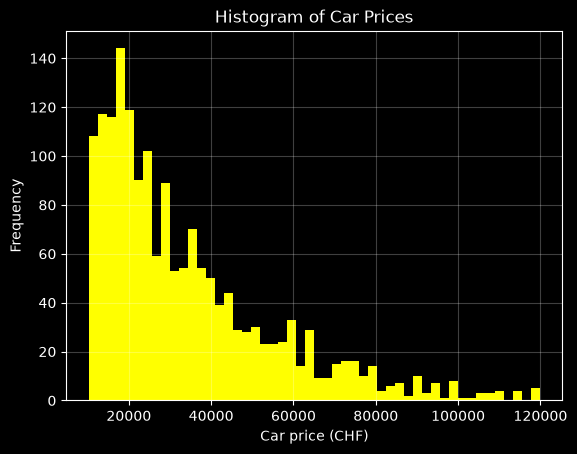

In [ ]:
# Create a histogram of car prices

plt.hist(df['Price'], bins=50, color='yellow')  #Histogramm der Fahrzeugpreise mit 50 Wertebereichen erstellen
plt.title('Histogram of Car Prices')            #Titel des Diagramms festlegen
plt.xlabel('Car price (CHF)')                   #Beschriftung der x-Achse festlegen
plt.ylabel('Frequency')                         #Beschriftung der y-Achse: Anzahl Fahrzeuge pro Preisbereich
plt.grid(alpha=0.25)                            #Gitternetz mit leichter Transparenz anzeigen
plt.show()                                      #Fertiges Diagramm anzeigen

## Define a query to aggregate the data

In [ ]:
def aggregate_prices_by_brand(database_name, coll_name, mongo_client=client):   #Funktion definieren, welche Fahrzeugpreise nach Marke aggregiert
    """Aggregate total, average, and count of car prices grouped by brand."""   #Kurzbeschreibung der Funktion
    database = mongo_client[database_name]                                      #Gewünschte MongoDB-Datenbank auswählen
    coll = database[coll_name]                                                  #Gewünschte Collection auswählen

    pipeline = [                                                                #MongoDB-Aggregation-Pipeline definieren
        {
            "$group": {                                                         #Dokumente nach einem bestimmten Feld gruppieren
                "_id": "$Marke",                                                #Fahrzeuge nach Marke gruppieren
                "totalPrice": {"$sum": "$Price"},                               #Summe aller Fahrzeugpreise pro Marke berechnen
                "averagePrice": {"$avg": "$Price"},                             #Durchschnittspreis pro Marke berechnen
                "count": {"$sum": 1},                                           #Anzahl Fahrzeuge pro Marke zählen
            }
        },
        {"$sort": {"totalPrice": -1}},                                          #Ergebnisse nach Gesamtpreis absteigend sortieren
    ]

    aggregation_results = list(coll.aggregate(pipeline))                        #Pipeline ausführen und Resultate als Liste speichern
    return aggregation_results                                                  #Aggregationsergebnisse zurückgeben

# Execute the aggregation query
results = aggregate_prices_by_brand("car_database", "car_collection")           #Funktion für die Fahrzeugdatenbank und Collection ausführen

# Convert the results into a Pandas DataFrame
df = pd.DataFrame(results)                                                      #MongoDB-Ergebnisse in einen pandas-DataFrame umwandeln

# Rename the '_id' column to 'Marke' for better readability
df.rename(columns={"_id": "Marke"}, inplace=True)                               #Spalte _id direkt im DataFrame in Marke umbenennen

# Display the DataFrame
df.head()                                                                       #Erste 5 Zeilen des DataFrames anzeigen

,Marke,totalPrice,averagePrice,count
0,MERCEDES-BENZ,16532886,33671.865580,491
1,BMW,15535552,28401.374771,547
2,AUDI,14362528,28384.442688,506
3,PORSCHE,13321621,61961.027907,215
4,VW,7145938,18512.792746,386


## Create bar chart of average car prices

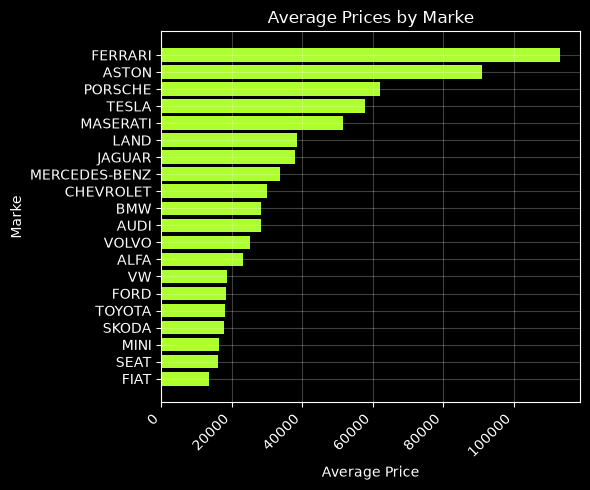

In [ ]:
# Select the first 20 vehicle brands and sort them by average price
df_sub = df.head(20).sort_values(by="averagePrice")     #Erste 20 Marken auswählen und nach Durchschnittspreis aufsteigend sortieren

# Create a bar chart
plt.figure(figsize=(6, 5))                              #Neue Grafik mit einer Grösse von 6 × 5 Zoll erstellen
plt.barh(
    df_sub["Marke"],                                    #Fahrzeugmarken auf der y-Achse anzeigen
    df_sub["averagePrice"],                             #Durchschnittspreise als Balkenlänge darstellen
    color="greenyellow",                                #Farbe der Balken festlegen
)
plt.title("Average Prices by Marke")                    #Titel des Diagramms festlegen
plt.xlabel("Average Price")                             #x-Achse mit Durchschnittspreis beschriften
plt.ylabel("Marke")                                     #y-Achse mit Marke beschriften
plt.grid(alpha=0.25)                                    #Gitternetz mit leichter Transparenz anzeigen
plt.xticks(rotation=45, ha="right")                     #x-Achsenbeschriftungen um 45° drehen und rechts ausrichten
plt.tight_layout()                                      #Abstände automatisch optimieren, damit nichts abgeschnitten wird

# Display the plot
plt.show()                                              #Fertiges Diagramm anzeigen

## Eigene MLQ Queries

In [8]:
#MQL = MongoDB Query Language: Abfragesprache für dokumentenbasierte MongoDB-Daten.
#Im Gegensatz zu SQL (Tabellen/Zeilen) arbeitet MQL mit Collections/Dokumenten und wird in PyMongo
#Typischerweise als Python-Dictionary mit Operatoren wie $gt, $lt, $eq oder $or geschrieben


#QUERY 1: Fahrzeuge mit einem Preis über CHF 80'000
#SQL equivalent: SELECT * FROM car_collection WHERE Price > 80000;
query_1 = {
    "Price": {"$gt": 80000}                                                 #$gt = greater than → Preis grösser als 80'000
}
results_1 = query_collection("car_database", "car_collection", query_1)     #MQL-Query ausführen
df_query_1 = pd.DataFrame(results_1)                                        #Ergebnisse in einen DataFrame umwandeln
df_query_1.head()                                                           #Erste 5 Ergebnisse anzeigen


#QUERY 2: Alle Fahrzeuge mit Benzinmotor
#SQL equivalent:
#SELECT * FROM car_collection WHERE Fuel_Type = 'Benzin';
query_2 = {
    "Fuel_Type": {"$eq": "Benzin"}                                          #$eq = equal → Fuel_Type muss Benzin entsprechen
}
results_2 = query_collection("car_database", "car_collection", query_2)     #MQL-Query ausführen
df_query_2 = pd.DataFrame(results_2)                                        #Ergebnisse in einen DataFrame umwandeln
df_query_2.head()                                                           #Erste 5 Ergebnisse anzeigen


#QUERY 3: Fahrzeuge mit einem Preis zwischen CHF 20'000 und CHF 50'000
#SQL equivalent:
#SELECT * FROM car_collection WHERE Price >= 20000 AND Price <= 50000;
query_3 = {
    "Price": {
        "$gte": 20000,                                                      #$gte = greater than or equal → mindestens 20'000
        "$lte": 50000                                                       #$lte = less than or equal → maximal 50'000
    }
}
results_3 = query_collection("car_database", "car_collection", query_3)     #MQL-Query ausführen
df_query_3 = pd.DataFrame(results_3)                                        #Ergebnisse in einen DataFrame umwandeln
df_query_3.head()                                                           #Erste 5 Ergebnisse anzeigen


#QUERY 4: Fahrzeuge mit mehr als 200 PS und einem Preis unter CHF 100'000
#SQL equivalent:
#SELECT * FROM car_collection WHERE PS > 200 AND Price < 100000;
query_4 = {
    "PS": {"$gt": 200},                                                     #Leistung muss grösser als 200 PS sein
    "Price": {"$lt": 100000}                                                #Preis muss kleiner als 100'000 sein
}                                                                           #Mehrere Bedingungen im Dictionary werden automatisch mit AND verknüpft
results_4 = query_collection("car_database", "car_collection", query_4)     #MQL-Query ausführen
df_query_4 = pd.DataFrame(results_4)                                        #Ergebnisse in einen DataFrame umwandeln
df_query_4.head()                                                           #Erste 5 Ergebnisse anzeigen


#QUERY 5: Fahrzeuge mit Benzinmotor ODER mehr als 300 PS
#SQL equivalent:
#SELECT * FROM car_collection WHERE Fuel_Type = 'Benzin' OR PS > 300;
query_5 = {
    "$or": [                                                                #$or = mindestens eine der folgenden Bedingungen muss erfüllt sein
        {"Fuel_Type": {"$eq": "Benzin"}},
        {"PS": {"$gt": 300}}
    ]
}

results_5 = query_collection("car_database", "car_collection", query_5)     #MQL-Query ausführen
df_query_5 = pd.DataFrame(results_5)                                        #Ergebnisse in einen DataFrame umwandeln
df_query_5.head()                                                           #Erste 5 Ergebnisse anzeigen

,_id,Offer_Id,Type,Init_Regist,Fuel_Type,Transmission,Dealer_Name,Dealer_PLZ,Dealer_City,Dealer_Street_House_Nr,Dealer_Telnr,Marke,Price,PS,Init_Regist_MY,Init_Regist_Month,Init_Regist_Year,Init_Regist_Dt
0,6ab84933cc9ee5eb38e8050c,7512768,MERCEDES-BENZ SLK 200 7G-Tronic (Cabriolet),6.2013,Benzin,Automat sequentiell,***confidential***,3186,Düdingen,***confidential***,***confidential***,MERCEDES-BENZ,23749,184,6.2013,6.0,2013.0,1.370045e+12
1,6ab84933cc9ee5eb38e8050d,7512034,MERCEDES-BENZ C 350 Avantgarde 4Matic 7G-Troni...,6.2011,Benzin,Automat sequentiell,***confidential***,1262,Eysins,***confidential***,***confidential***,MERCEDES-BENZ,18500,306,6.2011,6.0,2011.0,1.306886e+12
2,6ab84933cc9ee5eb38e8050e,7512728,MERCEDES-BENZ A 45 AMG 4Matic Speedshift 7G-DC...,8.2015,Benzin,Automatisiertes Schaltgetriebe,***confidential***,4314,Zeiningen,***confidential***,***confidential***,MERCEDES-BENZ,36000,360,8.2015,8.0,2015.0,1.438387e+12
3,6ab84933cc9ee5eb38e8050f,7490242,AUDI A5 Sportback 2.0 TFSI Sport quattro S-tro...,9.2018,Benzin,Automatisiertes Schaltgetriebe,***confidential***,3250,Lyss,***confidential***,***confidential***,AUDI,48500,252,9.2018,9.0,2018.0,1.535760e+12
4,6ab84933cc9ee5eb38e80510,7512188,MERCEDES-BENZ SLK 200 Kompressor (Cabriolet),12.2004,Benzin,Schaltgetriebe manuell,***confidential***,8832,Wollerau,***confidential***,***confidential***,MERCEDES-BENZ,12000,163,12.2004,12.0,2004.0,1.101859e+12


## Drop defined collections and databases

In [ ]:
#Kurz: Der Block räumt nach der Übung auf, indem zuerst car_collection und danach die gesamte car_database gelöscht werden.
# List databases

databases = client.list_database_names()                                    #Namen aller vorhandenen MongoDB-Datenbanken abrufen
print("Connected to MongoDB. Databases:", databases)                        #Vorhandene Datenbanken ausgeben

# Drop the defined collection and database if they exist

DB_NAME = "car_database"                                                    #Name der zu löschenden Datenbank festlegen
COLLECTION_NAME = "car_collection"                                          #Name der zu löschenden Collection festlegen
db = client[DB_NAME]                                                        #Datenbank car_database auswählen

if COLLECTION_NAME in db.list_collection_names():                           #Prüfen, ob die Collection existiert
    db.drop_collection(COLLECTION_NAME)                                     #Collection löschen
    print(
        f"Collection '{COLLECTION_NAME}' dropped from database "            #Erfolgsmeldung vorbereiten
        f"'{DB_NAME}'."                                                     #Datenbankname in die Meldung einsetzen
    )
else:  # Falls die Collection nicht existiert
    print(
        f"Collection '{COLLECTION_NAME}' does not exist in database "       #Hinweismeldung vorbereiten
        f"'{DB_NAME}'."                                                     #Datenbankname in die Meldung einsetzen
    )

# Drop the database

if DB_NAME in databases:                                                    #Prüfen, ob die Datenbank existiert
    client.drop_database(DB_NAME)                                           #Gesamte Datenbank löschen
    print(f"Database '{DB_NAME}' dropped.")                                 #Erfolgsmeldung ausgeben
else:                                                                       #Falls die Datenbank nicht existiert
    print(f"Database '{DB_NAME}' does not exist.")                          #Hinweismeldung ausgeben

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [ ]:
print("-" * 35)                                                   #Trennlinie aus 35 Bindestrichen ausgeben
print(os.name.upper())                                            #Namen des Betriebssystems in Grossbuchstaben anzeigen
print(platform.system(), "|", platform.release())                 #Betriebssystem und Release-Version anzeigen
print("Datetime:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))  #Aktuelles Datum und Uhrzeit formatiert ausgeben
print("Python Version:", python_version())                        #Aktuell verwendete Python-Version anzeigen
print("-" * 35)                                                   #Abschliessende Trennlinie ausgeben